In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sqlalchemy import create_engine

In [11]:
path = "data/StudentPerformanceFactors.csv"
df = pd.read_csv(path, sep=',', encoding='ISO-8859-1')

engine = create_engine("sqlite:///data/students.sqlite")
df.to_sql("students", engine, index=False, if_exists="replace")


6607

In [12]:
path_salary = "data/salary/Salary_Data.csv"
s_df = pd.read_csv(path_salary, sep=',', encoding='ISO-8859-1')

engine2 = create_engine("sqlite:///data/salary.sqlite")
s_df = s_df.rename(columns={"ï»¿Age": "Age", "Education Level":"Education_Level",
                            "Job Title":"Job", "Years of Experience":"Years_of_Experience"})

s_df.to_sql("salary", engine2, index=False, if_exists="replace")


6704

### Distribuition of male and female students in research
This pizza graph shows the proportion of male e and female students in the dataset.
Each slice represents one gender, with its percentage displayed over the respective slice. 

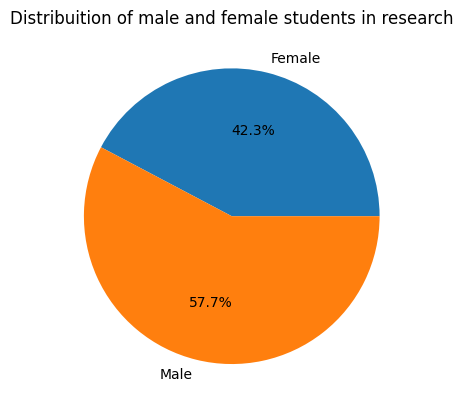

In [13]:
gender = pd.read_sql("SELECT Gender, count(*) as num FROM students GROUP BY Gender", engine)

plt.pie(gender['num'], labels=gender['Gender'], autopct='%1.1f%%')
plt.title("Distribuition of male and female students in research")
plt.show()



### Average scores per gender
The graphic below shows the mean scores that each gender obtained in previous exams.
Each bar represents the average performance for each gender.
The x axis show the average score and the y axis, identifies the gender. 
The interval between 70 and 78 in x axis indicates the both groups had a similar performance.

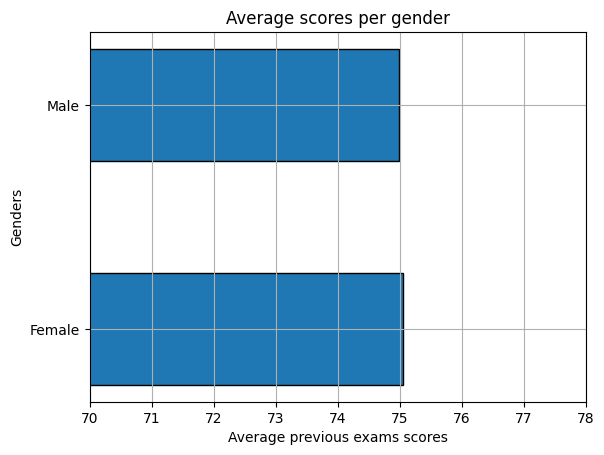

In [14]:
gender = pd.read_sql("SELECT Gender, AVG(Previous_Scores) as mean FROM (SELECT * FROM (SELECT * FROM students" \
                     " WHERE Gender = 'Male' " \
                     " LIMIT 2770)" \
                     " UNION ALL"
                     " SELECT * FROM " \
                     " (SELECT * FROM students" \
                     "  WHERE Gender = 'Female' LIMIT 2770))" \
                     " GROUP BY Gender", engine)

plt.barh(y=gender['Gender'], width=gender['mean'], edgecolor="black", height=0.5)
plt.title("Average scores per gender")
plt.xlabel("Average previous exams scores")
plt.ylabel("Genders")
plt.xlim(70, 78)
plt.grid(True)


### Average Salaries per age
This graphic shows the tendency of salary for each age.
The x axis represents the age of the person and the y axis represents their mean salary according to the values obtained in the dataset.

<Axes: title={'center': 'Average Salaries per age'}, xlabel='Age', ylabel='Salary in dollars'>

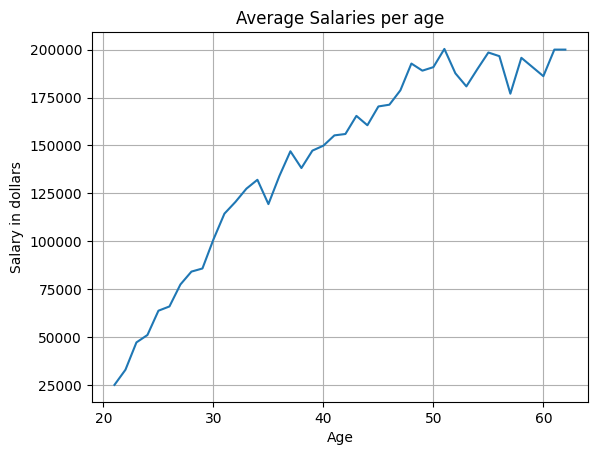

In [15]:

sleep = s_df.groupby(['Age'])['Salary'].mean()
sleep.plot(ylabel="Salary in dollars", title="Average Salaries per age", grid=True)


In [16]:
job_salaries = s_df.groupby(['Job'])['Salary'].agg(['min', 'max', 'mean'])
s_df = s_df.merge(job_salaries[['max']], left_on='Job', right_index=True, how='left')
s_df = s_df.rename(columns={'max': 'Biggest Salary per Job'})
s_df.head(10)


,Age,Gender,Education_Level,Job,Years_of_Experience,Salary,Biggest Salary per Job
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,197000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0,195000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0,170000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0,200000.0
5,29.0,Male,Bachelor's,Marketing Analyst,2.0,55000.0,75000.0
6,42.0,Female,Master's,Product Manager,12.0,120000.0,198000.0
7,31.0,Male,Bachelor's,Sales Manager,4.0,80000.0,180000.0
8,26.0,Female,Bachelor's,Marketing Coordinator,1.0,45000.0,131000.0
9,38.0,Male,PhD,Senior Scientist,10.0,110000.0,140000.0


In [17]:
path = f'loadings/salary.csv'
s_df.to_csv(path, sep=',')